In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"Employee Sample Data - A(1).xlsx")

In [3]:
df.head()

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date
0,E02387,Emily Davis,Sr. Manger,IT,Research & Development,Female,Black,55.0,2016-04-08,141604.0,0.15,United States,Seattle,2021-10-16
1,E04105,Theodore Dinh,Technical Architect,IT,Manufacturing,Male,Asian,59.0,1997-11-29,99975.0,0.00,China,Chongqing,NaT
2,E02572,Luna Sanders,Director,Finance,Speciality Products,Female,Caucasian,50.0,2006-10-26,163099.0,0.20,United States,Chicago,NaT
3,E02832,Penelope Jordan,Computer Systems Manager,IT,Manufacturing,Female,Caucasian,26.0,2019-09-27,84913.0,0.07,United States,Chicago,NaT
4,E01639,Austin Vo,Sr. Analyst,Finance,Manufacturing,Male,Asian,55.0,1995-11-20,95409.0,0.00,United States,Phoenix,NaT


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           1000 non-null   str           
 1   Full Name      998 non-null    str           
 2   Job Title      999 non-null    str           
 3   Department     998 non-null    str           
 4   Business Unit  1000 non-null   str           
 5   Gender         999 non-null    str           
 6   Ethnicity      993 non-null    str           
 7   Age            994 non-null    float64       
 8   Hire Date      993 non-null    datetime64[us]
 9   Annual Salary  989 non-null    float64       
 10  Bonus %        992 non-null    float64       
 11  Country        998 non-null    str           
 12  City           998 non-null    str           
 13  Exit Date      85 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(3), str(9)
memory usage: 109.5 KB


In [5]:
df.describe()

,Age,Hire Date,Annual Salary,Bonus %,Exit Date
count,994.000000,993,989.00000,992.000000,85
mean,44.369215,2012-04-17 22:56:11.601208,113372.62184,0.088972,2016-11-02 18:04:14.117647
min,25.000000,1992-01-09 00:00:00,40063.00000,0.000000,1994-12-18 00:00:00
25%,35.000000,2007-02-24 00:00:00,71234.00000,0.000000,2014-12-25 00:00:00
50%,45.000000,2014-02-20 00:00:00,96567.00000,0.000000,2019-05-23 00:00:00
75%,54.000000,2018-06-25 00:00:00,151027.00000,0.150000,2021-04-09 00:00:00
max,65.000000,2021-12-26 00:00:00,258498.00000,0.400000,2022-08-17 00:00:00
std,11.248162,NaN,53729.04678,0.118135,NaN


# Data Cleaning

In [6]:
df.isnull().sum()

EEID               0
Full Name          2
Job Title          1
Department         2
Business Unit      0
Gender             1
Ethnicity          7
Age                6
Hire Date          7
Annual Salary     11
Bonus %            8
Country            2
City               2
Exit Date        915
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_cleaned = df.dropna(subset=["Full Name"])

In [9]:
cat_columns = df.select_dtypes(include='str').columns.tolist()

print("Categorical columns:", cat_columns)
cat_columns.append('Hire Date')
cat_columns.append('Age')
cat_columns.remove('EEID')
cat_columns.remove('Full Name')
print("Categorical columns:", cat_columns)


Categorical columns: ['EEID', 'Full Name', 'Job Title', 'Department', 'Business Unit', 'Gender', 'Ethnicity', 'Country', 'City']
Categorical columns: ['Job Title', 'Department', 'Business Unit', 'Gender', 'Ethnicity', 'Country', 'City', 'Hire Date', 'Age']


In [10]:
for col in cat_columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

In [11]:
df_cleaned.isnull().sum()

EEID               0
Full Name          0
Job Title          0
Department         0
Business Unit      0
Gender             0
Ethnicity          0
Age                0
Hire Date          0
Annual Salary     11
Bonus %            8
Country            0
City               0
Exit Date        913
dtype: int64

In [12]:
num_columns = ['Annual Salary', 'Bonus %']

In [13]:
for col in num_columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

In [14]:
df_cleaned['Still Working'] = df_cleaned['Exit Date'].isnull()

# charts

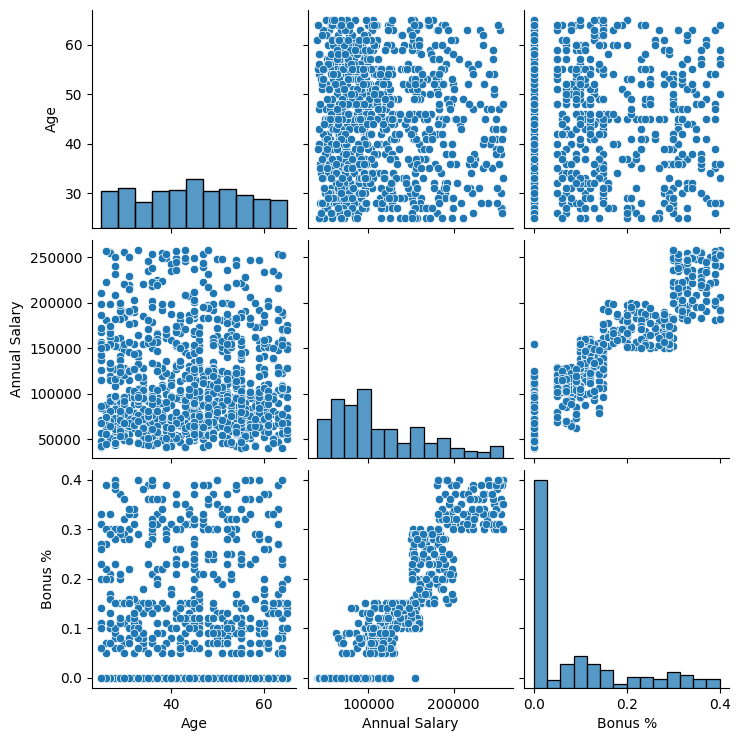

In [15]:
sns.pairplot(df_cleaned, x_vars = ['Age', 'Annual Salary', 'Bonus %'], y_vars = ['Age', 'Annual Salary', 'Bonus %'])


Text(0.5, 1.0, 'Age Distribution')

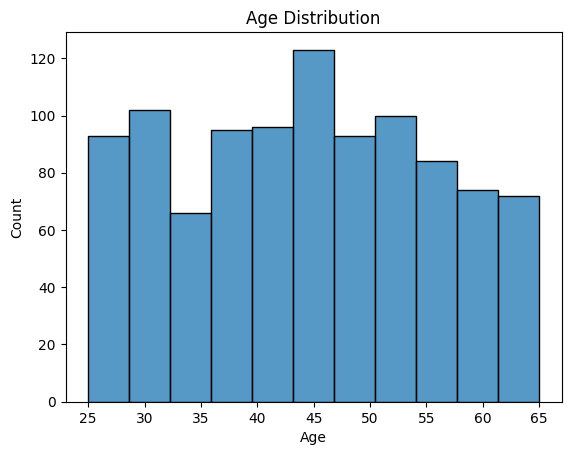

In [16]:
sns.histplot(df_cleaned, x = 'Age')
plt.title('Age Distribution')

Text(0.5, 1.0, 'Business Unit Distribution')

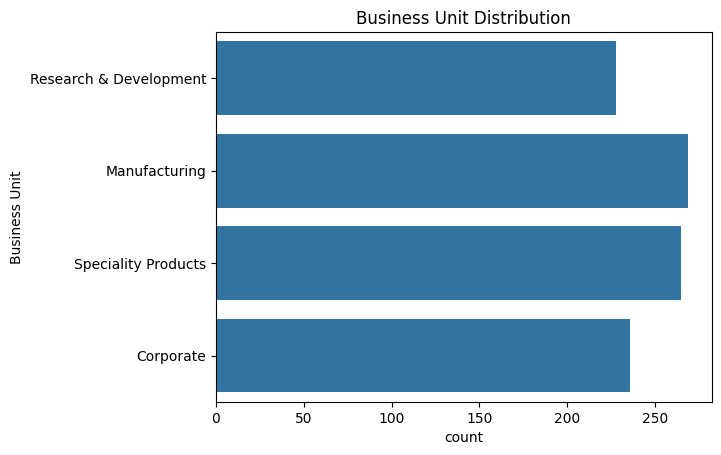

In [17]:
sns.countplot(df_cleaned['Business Unit'])
plt.title('Business Unit Distribution')

Text(0.5, 1.0, 'Department Distribution')

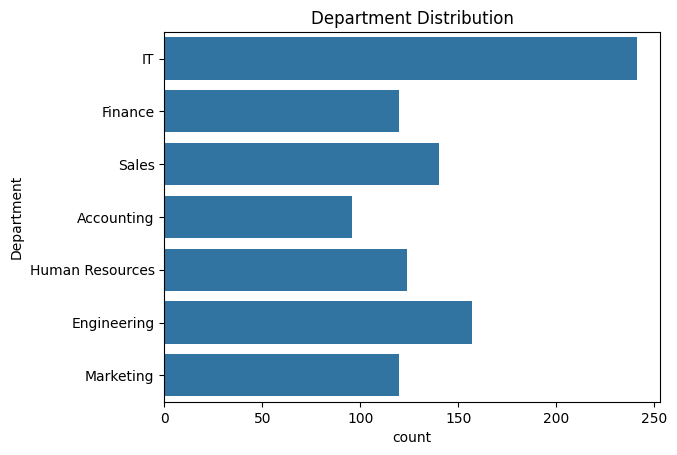

In [18]:
sns.countplot(df_cleaned['Department'])
plt.title('Department Distribution')

Text(0.5, 1.0, 'Annual Salary across Departments')

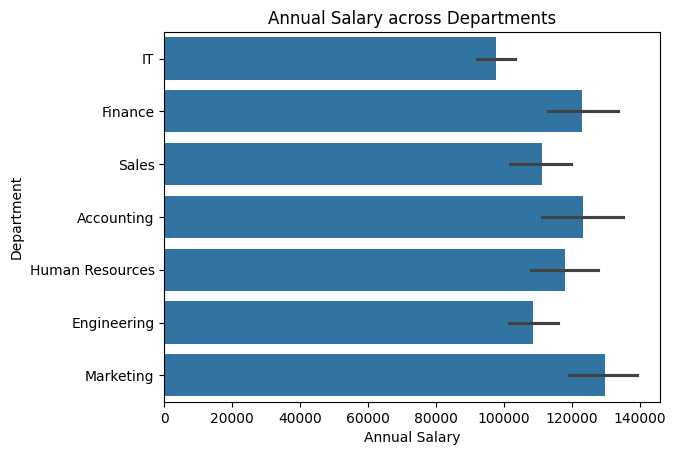

In [19]:
sns.barplot(df_cleaned, y = 'Department' , x = 'Annual Salary')
plt.title('Annual Salary across Departments')

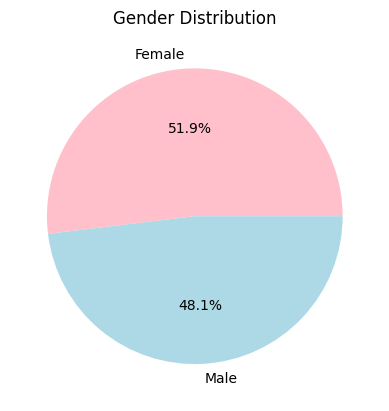

In [20]:
gender = df_cleaned['Gender'].value_counts()
gender_labels = gender.index
plt.pie(gender, labels = gender_labels, colors= ['pink','lightblue'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

Text(0.5, 1.0, 'Annual Salary across Gender')

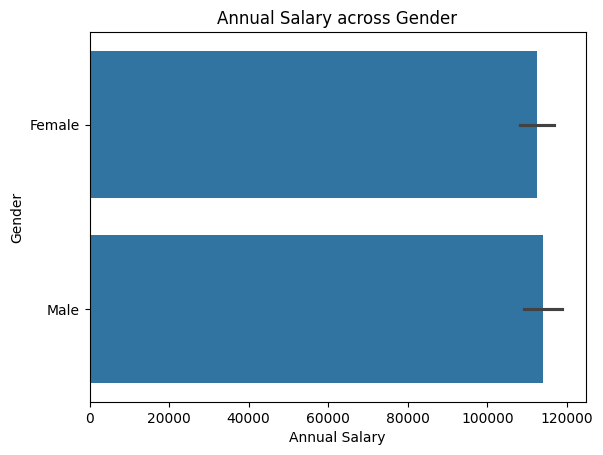

In [21]:
sns.barplot(df_cleaned, y = 'Gender' , x = 'Annual Salary')
plt.title('Annual Salary across Gender')

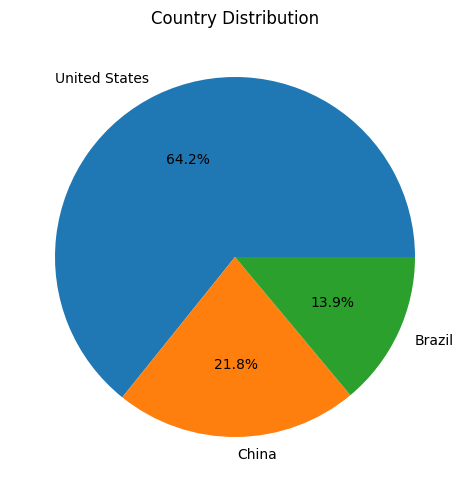

In [22]:
country = df_cleaned['Country'].value_counts()
country_labels = country.index
plt.pie(country, labels = country_labels, autopct='%1.1f%%')
plt.tight_layout()
plt.title('Country Distribution')
plt.show()

Text(0.5, 1.0, 'Annual Salary across Countries')

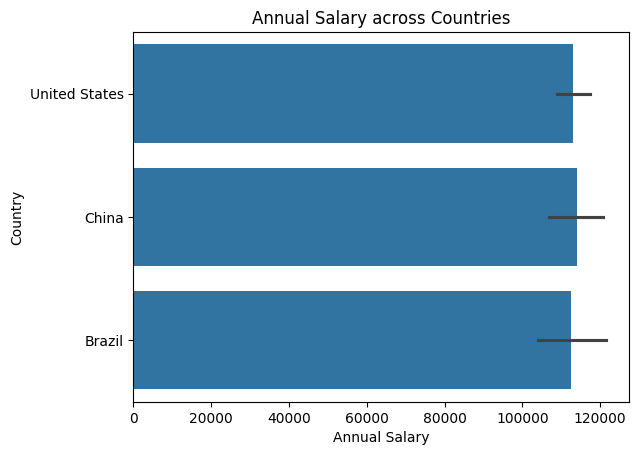

In [23]:
sns.barplot(df_cleaned, y = 'Country' , x = 'Annual Salary')
plt.title('Annual Salary across Countries')

Text(0.5, 1.0, 'Ethnicity Distribution')

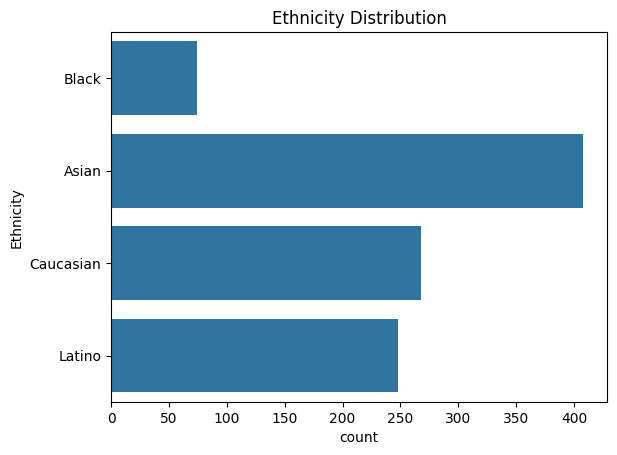

In [24]:
sns.countplot(df_cleaned['Ethnicity'])
plt.title('Ethnicity Distribution')

Text(0.5, 1.0, 'City Distribution')

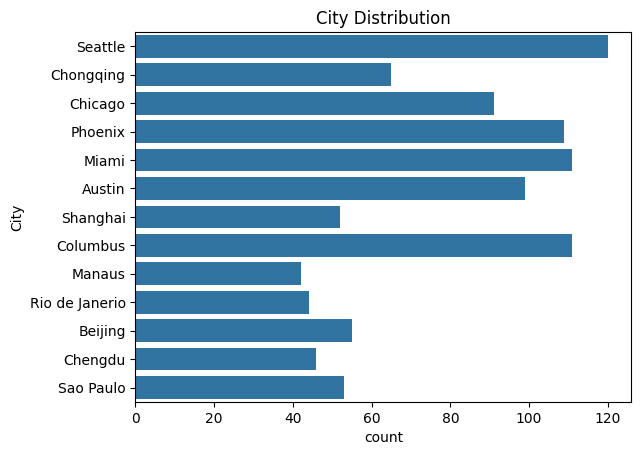

In [25]:
sns.countplot(df_cleaned['City'])
plt.title('City Distribution')

Text(0.5, 1.0, 'Still Working Distribution')

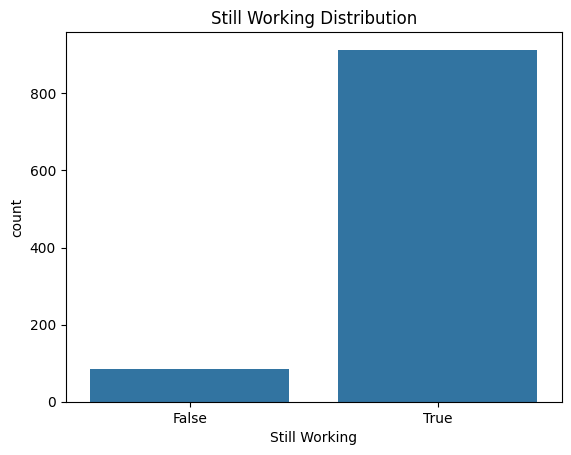

In [26]:
sns.countplot(df_cleaned, x = 'Still Working')
plt.title('Still Working Distribution')

In [27]:
zero_bonus = df[df['Bonus %'] == 0]

Text(0.5, 1.0, 'Distribution of Employees with 0 Bonus by Department')

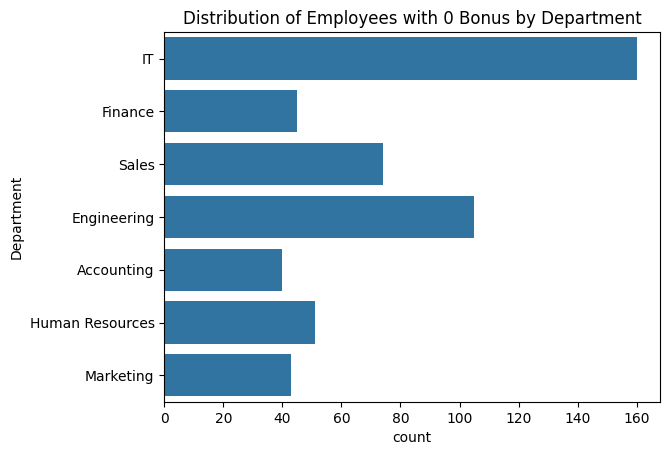

In [ ]:
sns.countplot(zero_bonus['Department'])
plt.title('Distribution of Employees with 0 Bonus by Department') 